# Graph Embedding

Try to get an embedding that incorporates both connectivity & firing rates

In [1]:
import numpy as np 
import sys
from matplotlib import pyplot as plt
import matplotlib.patches as patches
import scipy
import os
import importlib
import pandas as pd

sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld 
import single_neuron_utils as sn 
import bhv_utils as bhv
from bootstrap_method import *



In [2]:
delay = 150
condn_phrase = 'delay'
condn_num = 150

# condn_key = f'{condn_phrase}{condn_num}'

In [3]:
# find folder names within model directory
all_models_dir = '/home/nuttidalab/Documents/renee/all_DMS_models/'

model_dirs = ld.get_immediate_subdirs(all_models_dir)
print(model_dirs)


['Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_212818', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_163926', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_160648', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_165543', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_175711', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_174328', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_204320', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_212723', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_171227', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_154644', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_193816', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_163529', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_155744', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_172823', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_155628', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_163913', 'Task_x

In [4]:
# choose model 0 to visualize for now
model_name = model_dirs[1] # start w a good model
model_dir = os.path.join(all_models_dir, model_name)

# find files for this delay of interest
data_files = ld.find_files_keywords(model_dir, [f'delay{delay}'])
print(data_files)

['/home/nuttidalab/Documents/renee/all_DMS_models/Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_163926/neuraldata_raw_delay150.mat', '/home/nuttidalab/Documents/renee/all_DMS_models/Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_163926/bhvdata_raw_delay150.mat', '/home/nuttidalab/Documents/renee/all_DMS_models/Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_163926/timingdata_raw_delay150.mat']


In [6]:
# neural data
importlib.reload(ld)
lfp_data, spk_times_df, rates_data = ld.load_neural_data(model_name, condn_phrase, condn_num,
                                                  load_LFP=False, load_spikes=False, load_rates=True)
# behavioral data
trial_labels, trial_perfs = ld.load_bhv_data(model_name, condn_phrase='delay', condn_num=delay)

# timing data
_, times_real, fs_dict = ld.load_timing_data(model_name, condn_phrase='delay', condn_num=delay)
times_ms, _,_ = ld.get_times_dict('ds', condn_phrase, condn_num, model_name)

# get connectivity info
connectivity_df = ld.get_connectivity_df(model_name)

In [7]:
# restructure rate data

# get matrix of just mean firing rate for each neuron for each trial type (time x neurons x 4 trial types)
stim1_on = int(times_ms['stim1_on'])

t = int(rates_data.shape[0] - stim1_on)
rates_mean = np.zeros((t, rates_data.shape[1], 4))
trialtype_idxs = np.zeros((t*4))
trial_types, trial_idxs = np.unique(trial_labels, axis=0, return_inverse=True)
for i, trial_type in enumerate(trial_types):
    trials_idx = (trial_idxs == i)
    trialtype_idxs[i*t:(i+1)*t] = i
    # get mean rate
    rates_mean[:,:, i] = np.mean(rates_data[stim1_on:, :, trials_idx], axis=2)

print(rates_mean.shape)
print(trialtype_idxs.shape)

# concatenate 4 trial types one after another in time
rates_mean = rates_mean.transpose(2,0,1).reshape(-1, rates_mean.shape[1])
print(rates_mean.shape, trialtype_idxs.shape)

N = rates_mean.shape[1]

(1900, 200, 4)
(7600,)
(7600, 200) (7600,)


In [8]:
# get graph weights

W = ld.get_weights(model_name)
W.shape

(200, 200)

In [9]:
import networkx as nx
from sklearn.metrics import pairwise_distances
from sklearn.manifold import MDS
import matplotlib.pyplot as plt


def build_directed_graph(W):
    G = nx.DiGraph()
    N = W.shape[0]
    for i in range(N):
        for j in range(N):
            if W[i, j] != 0:
                G.add_edge(i, j, weight=W[i, j])
    return G


In [ ]:
def compute_graph_laplacian(G):
    A = nx.adjacency_matrix(G).todense()
    D = np.diag(np.sum(A, axis=1))  # Degree matrix
    L = D - A  # Laplacian matrix

    return L


In [179]:
def compute_graph_laplacian_signed(G):
    A = nx.to_numpy_array(G, weight='weight')
    abs_A = np.abs(A)
    D = np.diag(np.sum(abs_A, axis=1))  # Degree matrix
    L = D - A
    return L

In [11]:
def get_rate_features(r, normalize=True):
    if normalize:
        r = (r - r.mean(axis=1, keepdims=True)) / (r.std(axis=1, keepdims=True) + 1e-8)
    return r  # shape (200, T)


In [215]:
def concatenated_distance(rate_features, graph_distances):
    # Concatenate the rate features and graph distances
    concatenated_features = np.concatenate((rate_features, graph_distances), axis=1)
    return concatenated_features

In [12]:
def combined_distance(rate_features, graph_distances, alpha=0.5):
    # Normalize distances
    rate_dist = pairwise_distances(rate_features, metric='euclidean')
    rate_dist /= np.max(rate_dist)
    graph_dist = graph_distances.copy()
    graph_dist[graph_dist == np.inf] = np.max(graph_dist[graph_dist != np.inf])
    graph_dist /= np.max(graph_dist)

    combined = alpha * rate_dist + (1 - alpha) * graph_dist
    return combined


In [13]:
def embed_neurons(dist_matrix, dim=2):
    mds = MDS(n_components=dim, dissimilarity='precomputed', random_state=42)
    embedding = mds.fit_transform(dist_matrix)
    return embedding


In [92]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from umap import UMAP


def embed_tsne(dist_matrix, dim=2):
    tsne = TSNE(n_components=dim, metric='precomputed', random_state=42)
    embedding = tsne.fit_transform(dist_matrix)
    return embedding

def embed_umap(dist_matrix, dim=2):
    umap = UMAP(n_components=dim, random_state=42)
    embedding = umap.fit_transform(dist_matrix)
    return embedding

def embed_pca(dist_matrix, dim=2):
    pca = PCA(n_components=dim)
    embedding = pca.fit_transform(dist_matrix)
    return embedding

In [38]:
def plot_embedding(embedding):
    plt.figure(figsize=(8, 6))
    plt.scatter(embedding[:, 0], embedding[:, 1], c='red', s=30)
    plt.title("Neuron Embedding via Structural + Functional UMAP")
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
    plt.grid(True)
    plt.show()


In [18]:
def neural_embedding_pipeline(W, r, alpha=0.5):
    G = build_directed_graph(W)
    rate_features = get_rate_features(r)
    # graph_distances = compute_graph_distances(G, W.shape[0])
    graph_distances = compute_graph_laplacian(G)
    dist_matrix = combined_distance(rate_features, graph_distances, alpha=alpha)
    embedding = embed_neurons(dist_matrix)
    return embedding


In [24]:
G = build_directed_graph(W)
rate_features = get_rate_features(rates_mean.T)
# graph_distances = compute_graph_distances(G, W.shape[0])
graph_distances = compute_graph_laplacian(G)
dist_matrix = combined_distance(rate_features, graph_distances, alpha=0.5)

print(dist_matrix.shape)

(200, 200)


In [176]:
def build_directed_graph_pos(W):
    G = nx.DiGraph()
    N = W.shape[0]
    for i in range(N):
        for j in range(N):
            if W[i, j] != 0:
                G.add_edge(i, j, weight=np.abs(W[j, i]))
    return G


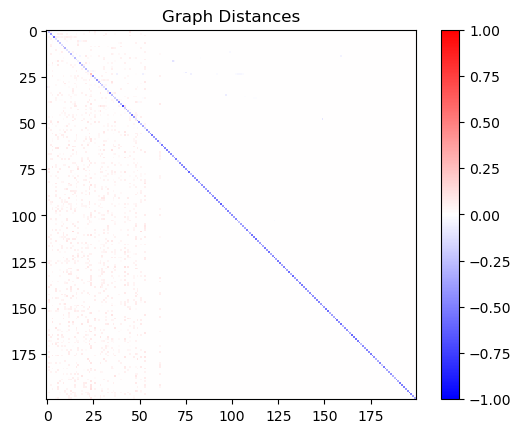

In [28]:
plt.imshow(graph_distances, cmap='bwr', interpolation='nearest', vmin=-1, vmax=1)
plt.colorbar()
plt.title("Graph Distances")
plt.show()

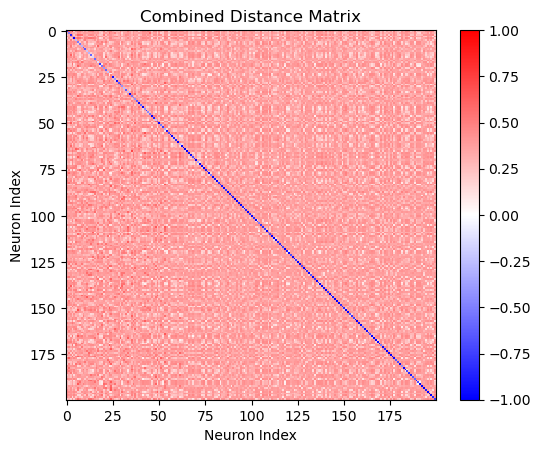

In [30]:
plt.imshow(dist_matrix, cmap='bwr', interpolation='nearest', vmin=-1, vmax=1)
plt.colorbar()
plt.title("Combined Distance Matrix")
plt.xlabel("Neuron Index")
plt.ylabel("Neuron Index")
plt.show()

/home/nuttidalab/miniconda3/envs/rnn_test/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


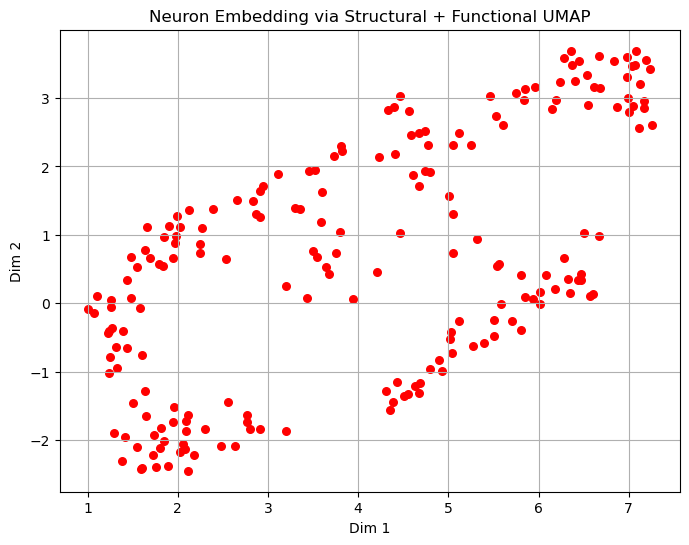

In [94]:
embedding = embed_umap(dist_matrix, dim=2)
plot_embedding(embedding)

In [181]:
signed_graph_distances = compute_graph_laplacian_signed(G)
dist_matrix_signed = combined_distance(rate_features, signed_graph_distances, alpha=0.5)
embedding_signed = embed_umap(dist_matrix)

/home/nuttidalab/miniconda3/envs/rnn_test/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


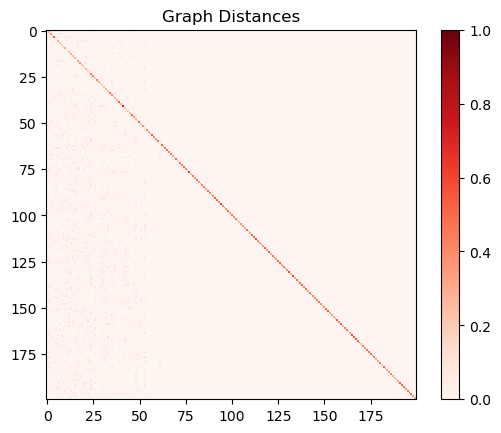

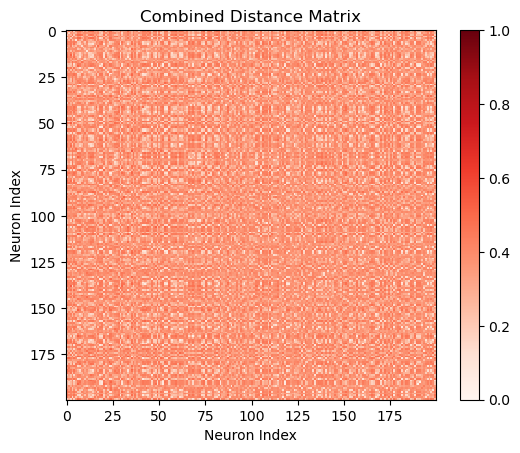

In [214]:
plt.imshow(signed_graph_distances, cmap='Reds', interpolation='nearest', vmin=0, vmax=1)
plt.colorbar()
plt.title("Graph Distances")
plt.show()

plt.imshow(dist_matrix_signed, cmap='Reds', interpolation='nearest', vmin=0, vmax=1)
plt.colorbar()
plt.title("Combined Distance Matrix")
plt.xlabel("Neuron Index")
plt.ylabel("Neuron Index")
plt.show()

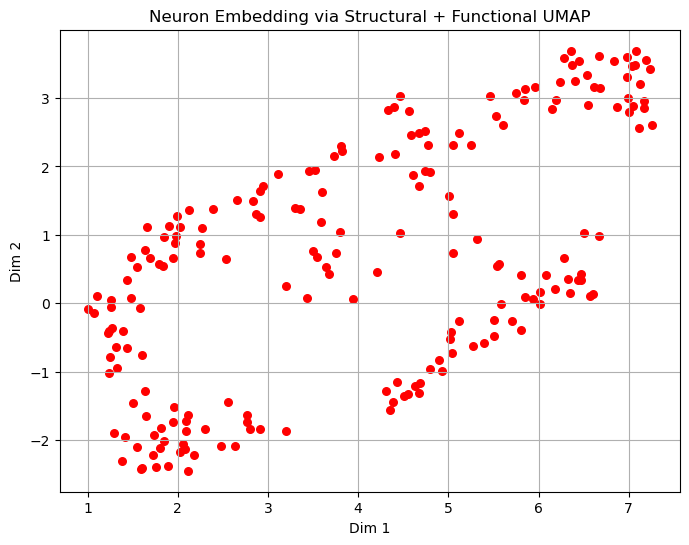

In [184]:
plot_embedding(embedding_signed)

In [42]:
exc_ind, inh_ind = ld.get_celltype_label(model_name)
exc = np.zeros(N)
exc[exc_ind] = 1

In [49]:
importlib.reload(sn)
tuning = sn.calc_stim1_tuning(model_name, condn_phrase, condn_num, rates_data=rates_data)
# replace nan's with zeros
tuning[np.isnan(tuning)] = 0

In [59]:
# create new scale that includes tuning and exc/inh
scale = tuning.copy()
scale = scale + 2 # +1 is 3, -1 is 1, 0 is 2
scale[exc_ind] = scale[exc_ind] * -1 # exc neurons negative
scale *= -1 # flip so inh negative

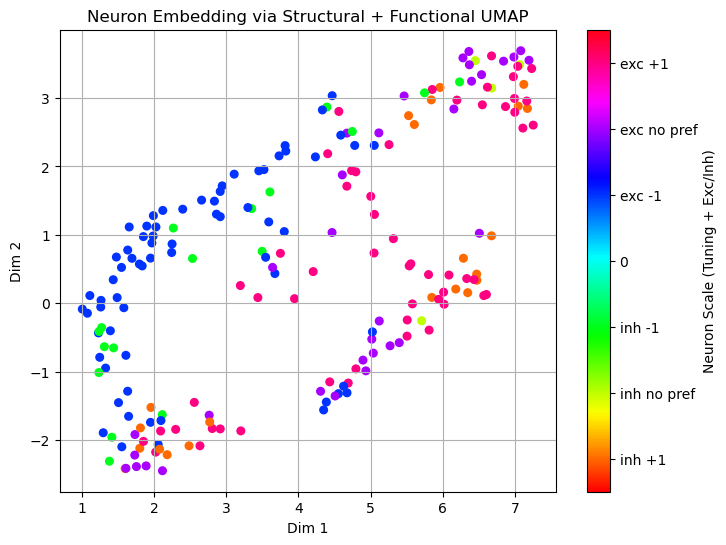

In [186]:
plt.figure(figsize=(8, 6))
plt.scatter(embedding_signed[:, 0], embedding_signed[:, 1], c= scale, s=30, cmap='hsv', vmin=-3.5, vmax=3.5)
# colorbar labels
cbar = plt.colorbar(label='Neuron Scale (Tuning + Exc/Inh)')
cbar.set_ticks([-3, -2, -1, 0, 1, 2, 3])
cbar.set_ticklabels(['inh +1', 'inh no pref', 'inh -1', '0', 'exc -1', 'exc no pref', 'exc +1'])
plt.title("Neuron Embedding via Structural + Functional UMAP")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.grid(True)
plt.show()


/home/nuttidalab/miniconda3/envs/rnn_test/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


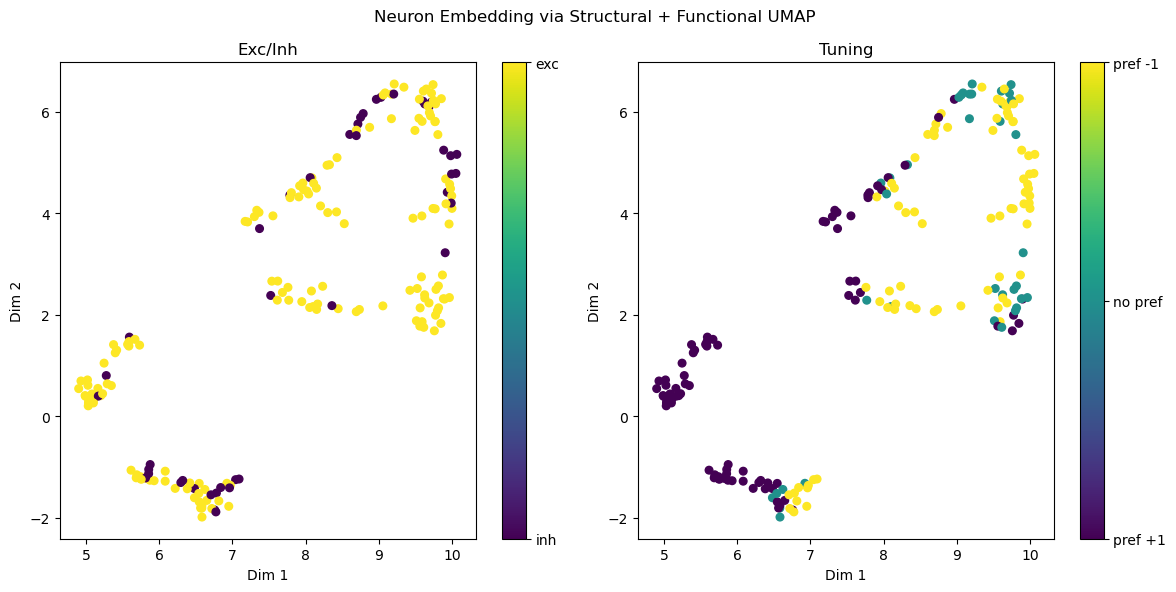

In [195]:
embedding_signed = embed_umap(dist_matrix_signed, dim=5)
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
colors = [exc, tuning]
titles = ["Exc/Inh", "Tuning"]
for i, ax in enumerate(axs):
    sc = ax.scatter(embedding_signed[:, 0], embedding_signed[:, 1], c=colors[i], s=30)
    ax.set_title(titles[i])
    ax.set_xlabel("Dim 1")
    ax.set_ylabel("Dim 2")
    # fig.colorbar(sc, ax=ax)

# add colorbar labels
cbar = fig.colorbar(sc, ax=axs[0])
cbar.set_ticks([-1, 1])
cbar.set_ticklabels(['inh', 'exc'])
cbar = fig.colorbar(sc, ax=axs[1])
cbar.set_ticks([-1, 0, 1])
cbar.set_ticklabels(['pref +1','no pref','pref -1'])

plt.suptitle("Neuron Embedding via Structural + Functional UMAP")
plt.tight_layout()
plt.show()

/home/nuttidalab/miniconda3/envs/rnn_test/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


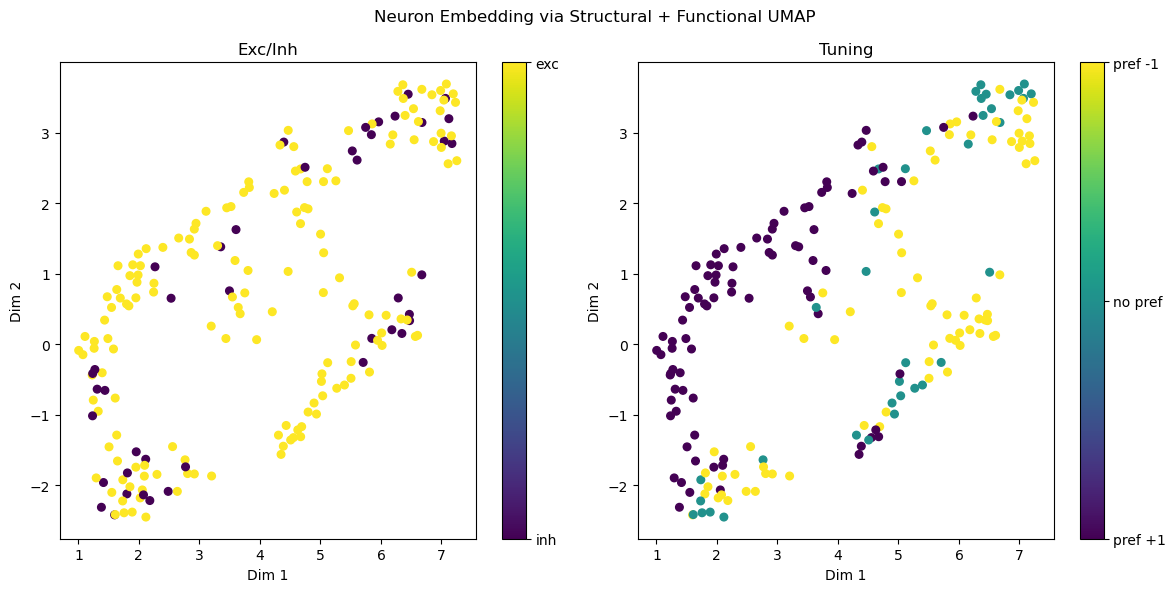

In [96]:
embedding = embed_umap(dist_matrix, dim=2)
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
colors = [exc, tuning]
titles = ["Exc/Inh", "Tuning"]
for i, ax in enumerate(axs):
    sc = ax.scatter(embedding[:, 0], embedding[:, 1], c=colors[i], s=30)
    ax.set_title(titles[i])
    ax.set_xlabel("Dim 1")
    ax.set_ylabel("Dim 2")
    # fig.colorbar(sc, ax=ax)

# add colorbar labels
cbar = fig.colorbar(sc, ax=axs[0])
cbar.set_ticks([-1, 1])
cbar.set_ticklabels(['inh', 'exc'])
cbar = fig.colorbar(sc, ax=axs[1])
cbar.set_ticks([-1, 0, 1])
cbar.set_ticklabels(['pref +1','no pref','pref -1'])

plt.suptitle("Neuron Embedding via Structural + Functional UMAP")
plt.tight_layout()
plt.show()

/home/nuttidalab/miniconda3/envs/rnn_test/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


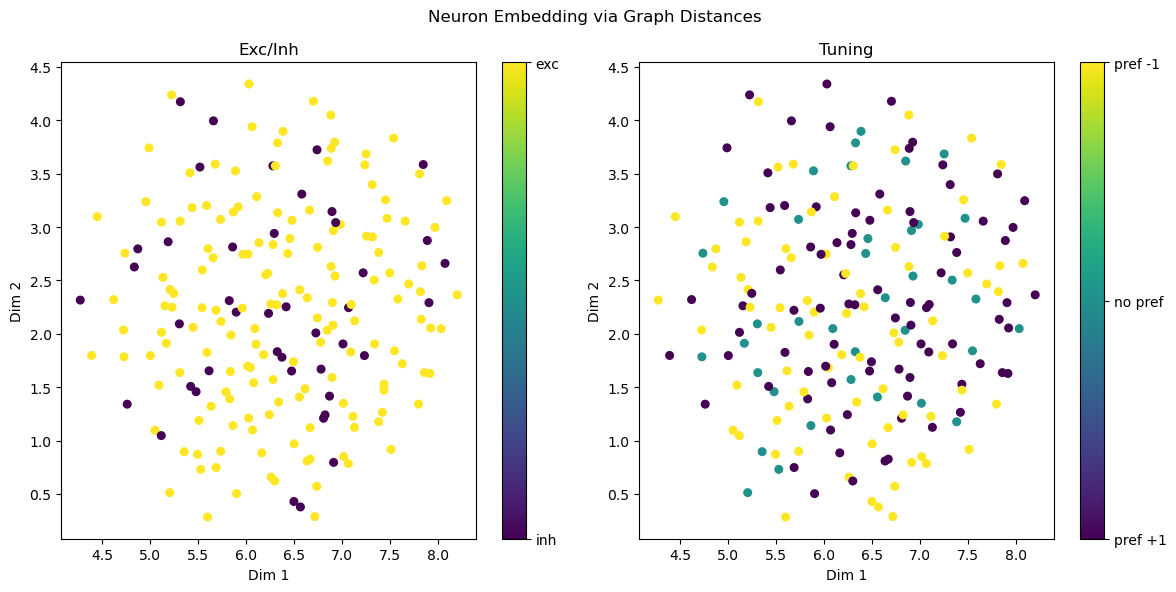

In [97]:
embedding_graph = embed_umap(graph_distances, dim=2)
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
colors = [exc, tuning]
titles = ["Exc/Inh", "Tuning"]
for i, ax in enumerate(axs):
    sc = ax.scatter(embedding_graph[:, 0], embedding_graph[:, 1], c=colors[i], s=30)
    ax.set_title(titles[i])
    ax.set_xlabel("Dim 1")
    ax.set_ylabel("Dim 2")
    # fig.colorbar(sc, ax=ax)

# add colorbar labels
cbar = fig.colorbar(sc, ax=axs[0])
cbar.set_ticks([-1, 1])
cbar.set_ticklabels(['inh', 'exc'])
cbar = fig.colorbar(sc, ax=axs[1])
cbar.set_ticks([-1, 0, 1])
cbar.set_ticklabels(['pref +1','no pref','pref -1'])

plt.suptitle("Neuron Embedding via Graph Distances")
plt.tight_layout()
plt.show()

/home/nuttidalab/miniconda3/envs/rnn_test/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


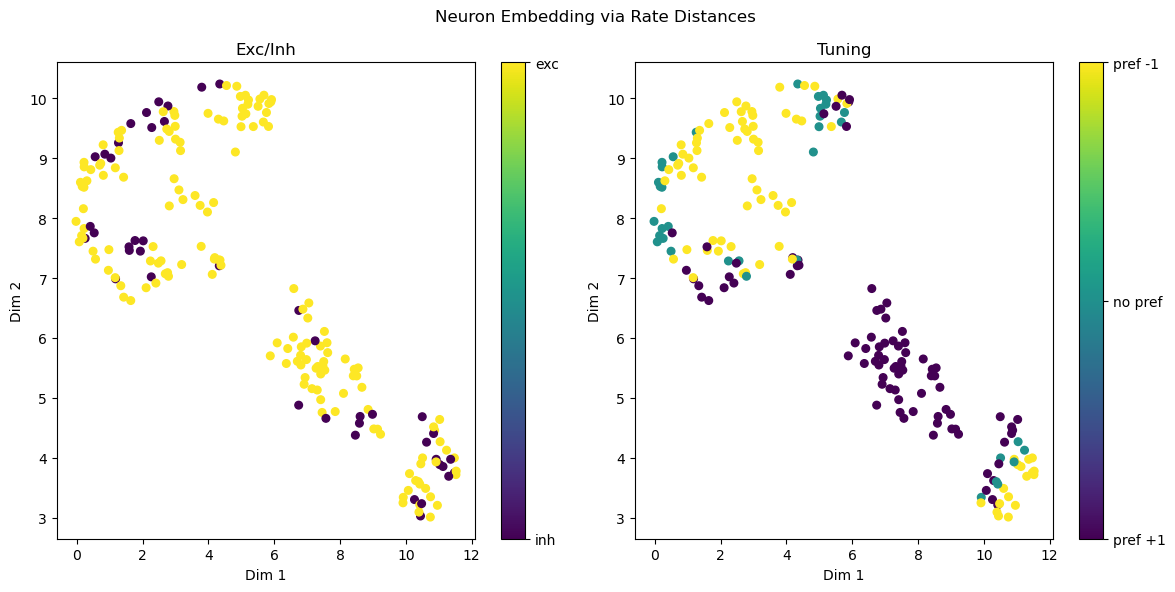

In [98]:


embedding_rate = embed_umap(rate_features, dim=2)
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
colors = [exc, tuning]
titles = ["Exc/Inh", "Tuning"]
for i, ax in enumerate(axs):
    sc = ax.scatter(embedding_rate[:, 0], embedding_rate[:, 1], c=colors[i], s=30)
    ax.set_title(titles[i])
    ax.set_xlabel("Dim 1")
    ax.set_ylabel("Dim 2")
    # fig.colorbar(sc, ax=ax)

# add colorbar labels
cbar = fig.colorbar(sc, ax=axs[0])
cbar.set_ticks([-1, 1])
cbar.set_ticklabels(['inh', 'exc'])
cbar = fig.colorbar(sc, ax=axs[1])
cbar.set_ticks([-1, 0, 1])
cbar.set_ticklabels(['pref +1','no pref','pref -1'])

plt.suptitle("Neuron Embedding via Rate Distances")
plt.tight_layout()
plt.show()

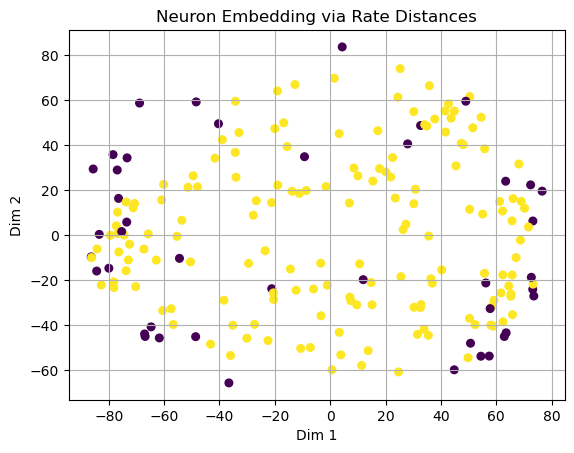

In [99]:
embedding_rate = embed_pca(rate_features, dim=2)
plt.scatter(embedding_rate[:, 0], embedding_rate[:, 1], c=exc, s=30)
plt.title("Neuron Embedding via Rate Distances")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.grid(True)
plt.show()

/home/nuttidalab/miniconda3/envs/rnn_test/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


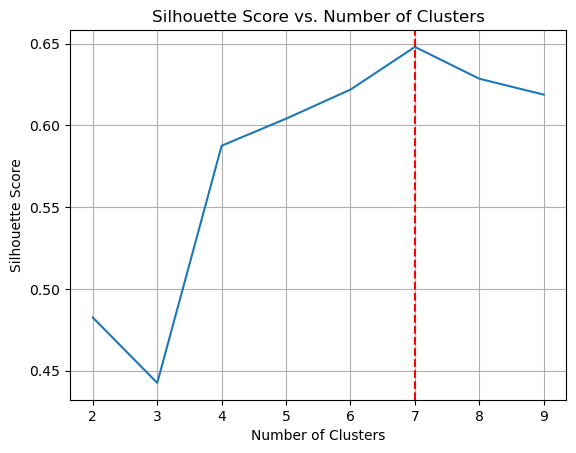

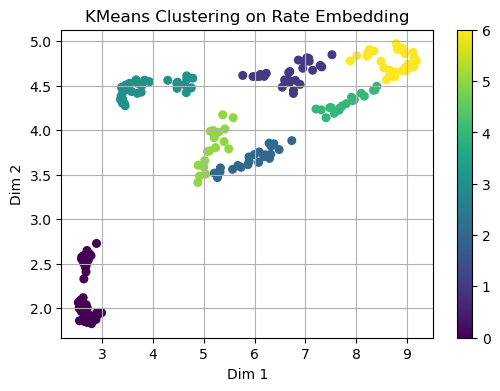

In [208]:
# try on signed data

# do kmeans clustering on embedding

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

embedding_signed = embed_umap(dist_matrix_signed, dim=20)

scores = []
for k in range(2,10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(embedding_signed)
    labels = kmeans.labels_
    score = silhouette_score(embedding_signed, labels)
    scores.append(score)
    best_k = k if (score == max(scores)) else best_k
plt.plot(range(2,10), scores)
plt.axvline(x=best_k, color='r', linestyle='--')
plt.title("Silhouette Score vs. Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

kmeans = KMeans(n_clusters=best_k, random_state=42)
kmeans.fit(embedding_signed)
labels = kmeans.labels_
plt.figure(figsize=(6,4))
plt.scatter(embedding_signed[:, 0], embedding_signed[:, 1], c=labels, s=30)
plt.title("KMeans Clustering on Rate Embedding")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.grid(True)
plt.colorbar()
plt.show()

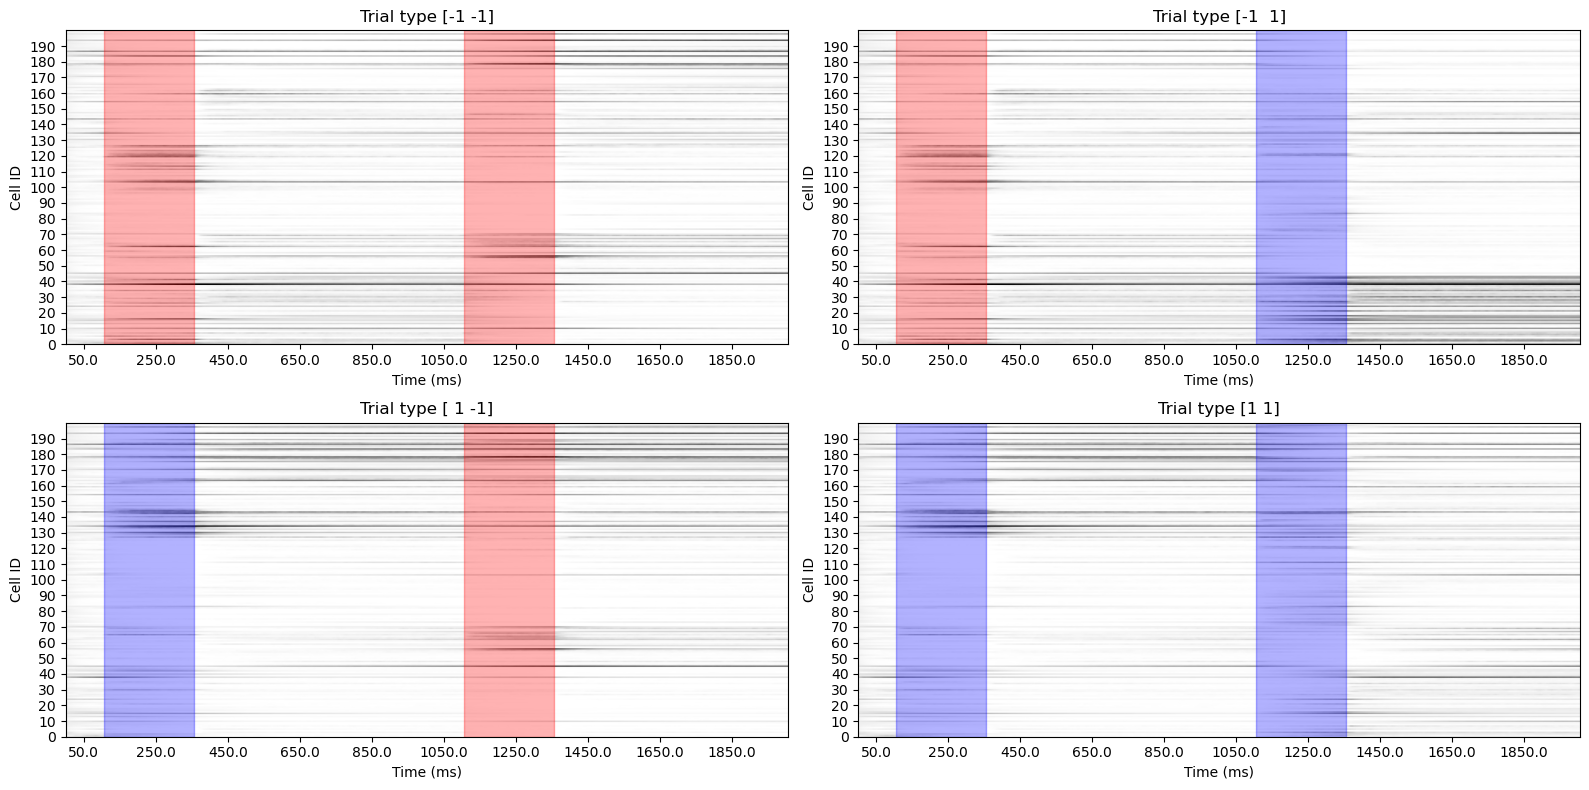

In [211]:
importlib.reload(sn)
sort = np.argsort(labels)
sn.plot_trialtype_meanrates(model_name, condn_phrase, condn_num, rates_data = rates_data, cut_off=50, sort=sort)

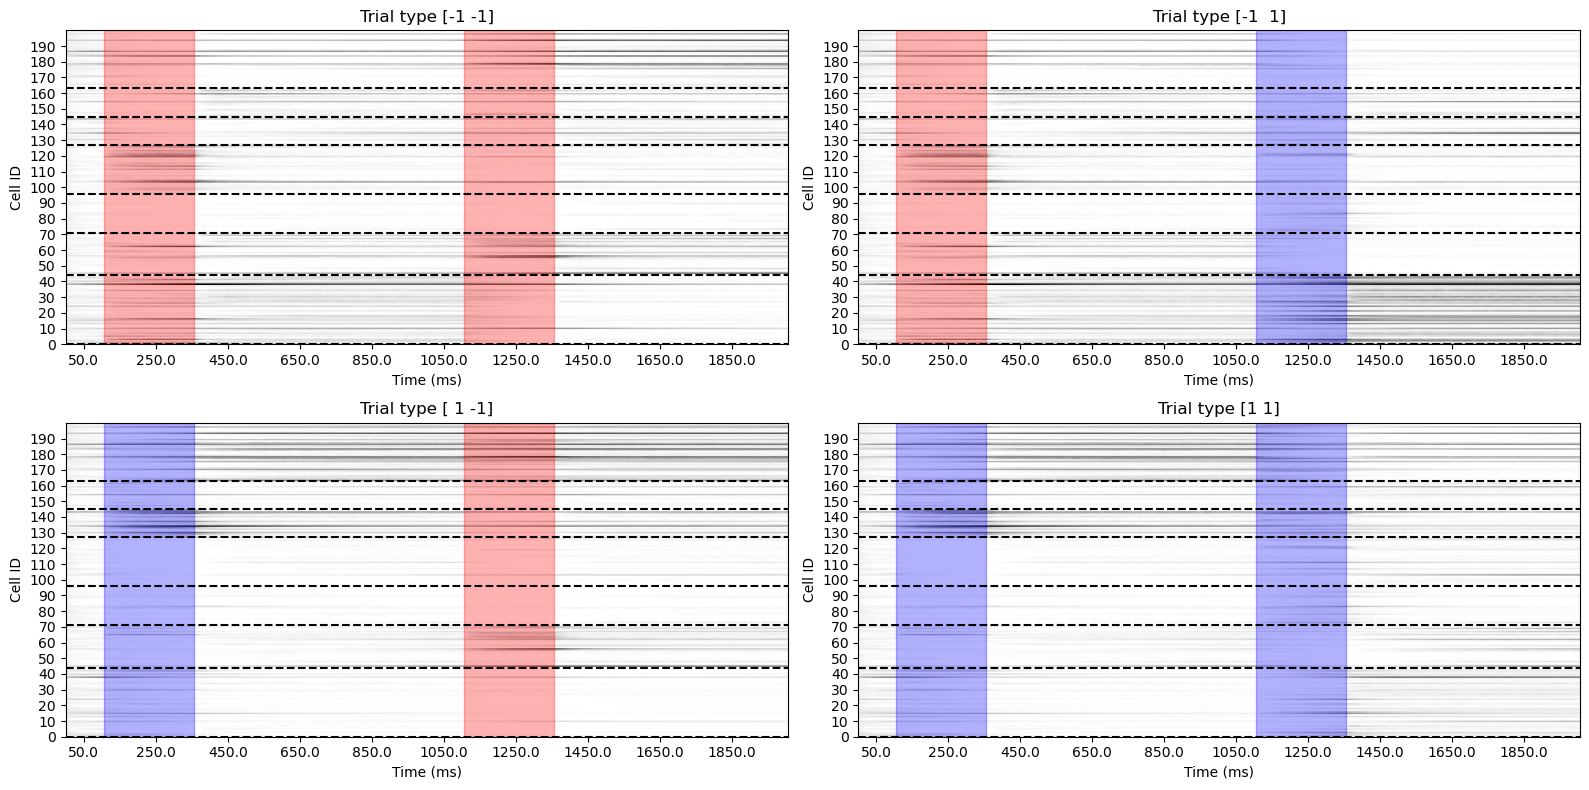

In [ ]:
importlib.reload(sn)
sort = np.argsort(labels)
_, hlines = np.unique(np.sort(labels), return_index=True)
sn.plot_trialtype_meanrates(model_name, condn_phrase, condn_num, rates_data = rates_data, cut_off=50, sort=sort, hlines=hlines)

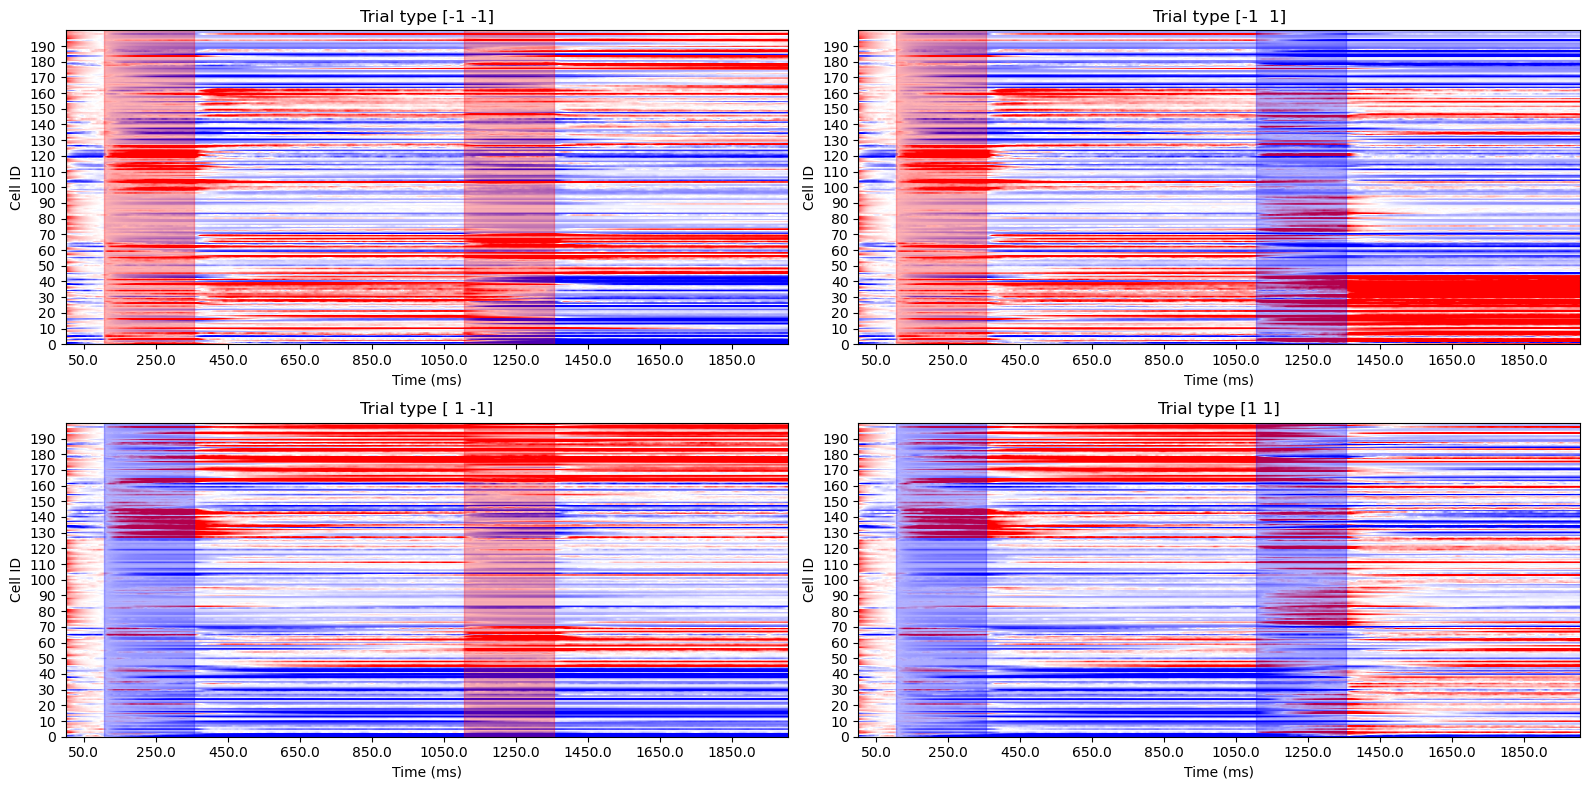

In [209]:
importlib.reload(sn)
sort = np.argsort(labels)
_, hlines = np.unique(np.sort(labels), return_index=True)
sn.plot_trialtype_meanrates(model_name, condn_phrase, condn_num, rates_data = rates_data, cut_off=50, sort=sort, normalize=True,
                            hlines = [])
# baseline subtracted

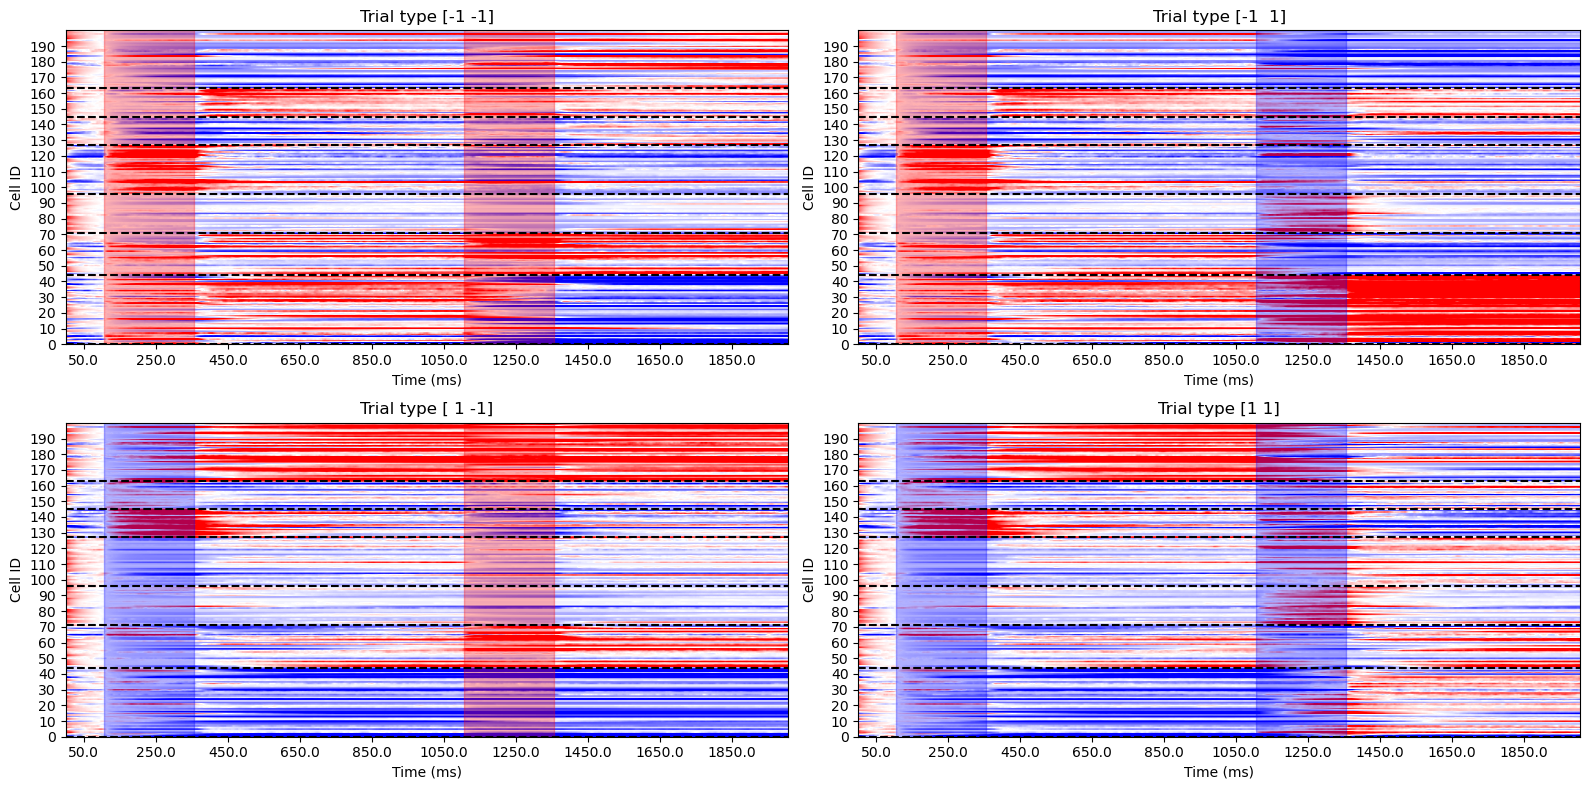

In [210]:
importlib.reload(sn)
sort = np.argsort(labels)
_, hlines = np.unique(np.sort(labels), return_index=True)
sn.plot_trialtype_meanrates(model_name, condn_phrase, condn_num, rates_data = rates_data, cut_off=50, sort=sort, normalize=True,
                            hlines = hlines)
# baseline subtracted

(200, 7800)


/home/nuttidalab/miniconda3/envs/rnn_test/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


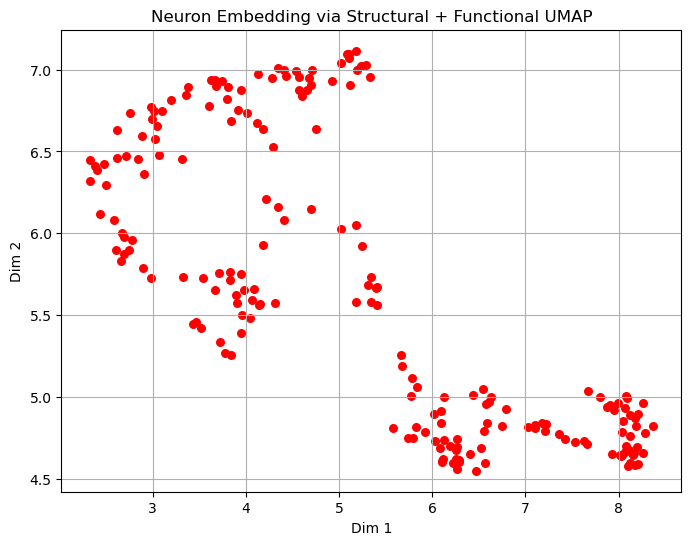

In [ ]:
concat_matrix = concatenated_distance(rate_features, graph_distances)
print(concat_matrix.shape)
embedding_concat = embed_umap(concat_matrix, dim=20)
plot_embedding(embedding_concat)

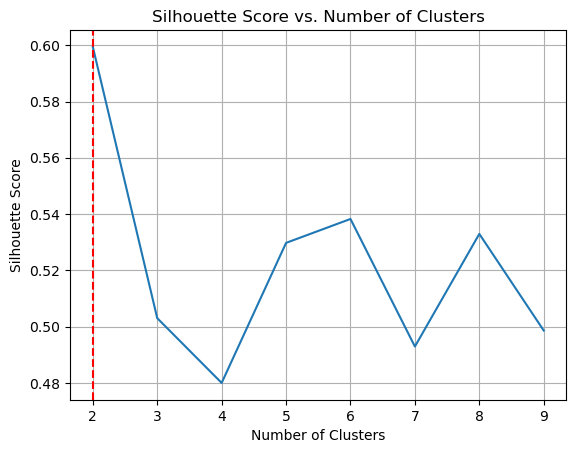

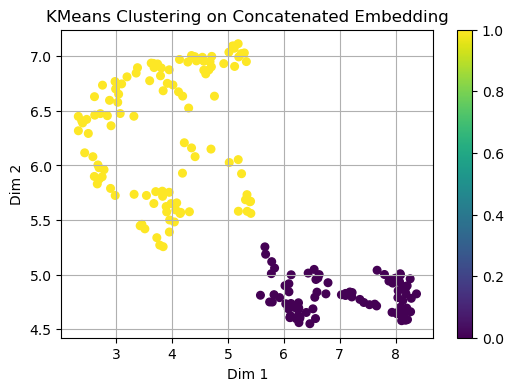

In [223]:
# try on signed data

# do kmeans clustering on embedding

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scores = []
for k in range(2,10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(embedding_concat)
    labels = kmeans.labels_
    score = silhouette_score(embedding_concat, labels)
    scores.append(score)
    best_k = k if (score == max(scores)) else best_k
plt.plot(range(2,10), scores)
plt.axvline(x=best_k, color='r', linestyle='--')
plt.title("Silhouette Score vs. Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

kmeans = KMeans(n_clusters=best_k, random_state=42)
kmeans.fit(embedding_concat)
labels = kmeans.labels_
plt.figure(figsize=(6,4))
plt.scatter(embedding_concat[:, 0], embedding_concat[:, 1], c=labels, s=30)
plt.title("KMeans Clustering on Concatenated Embedding")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.grid(True)
plt.colorbar()
plt.show()

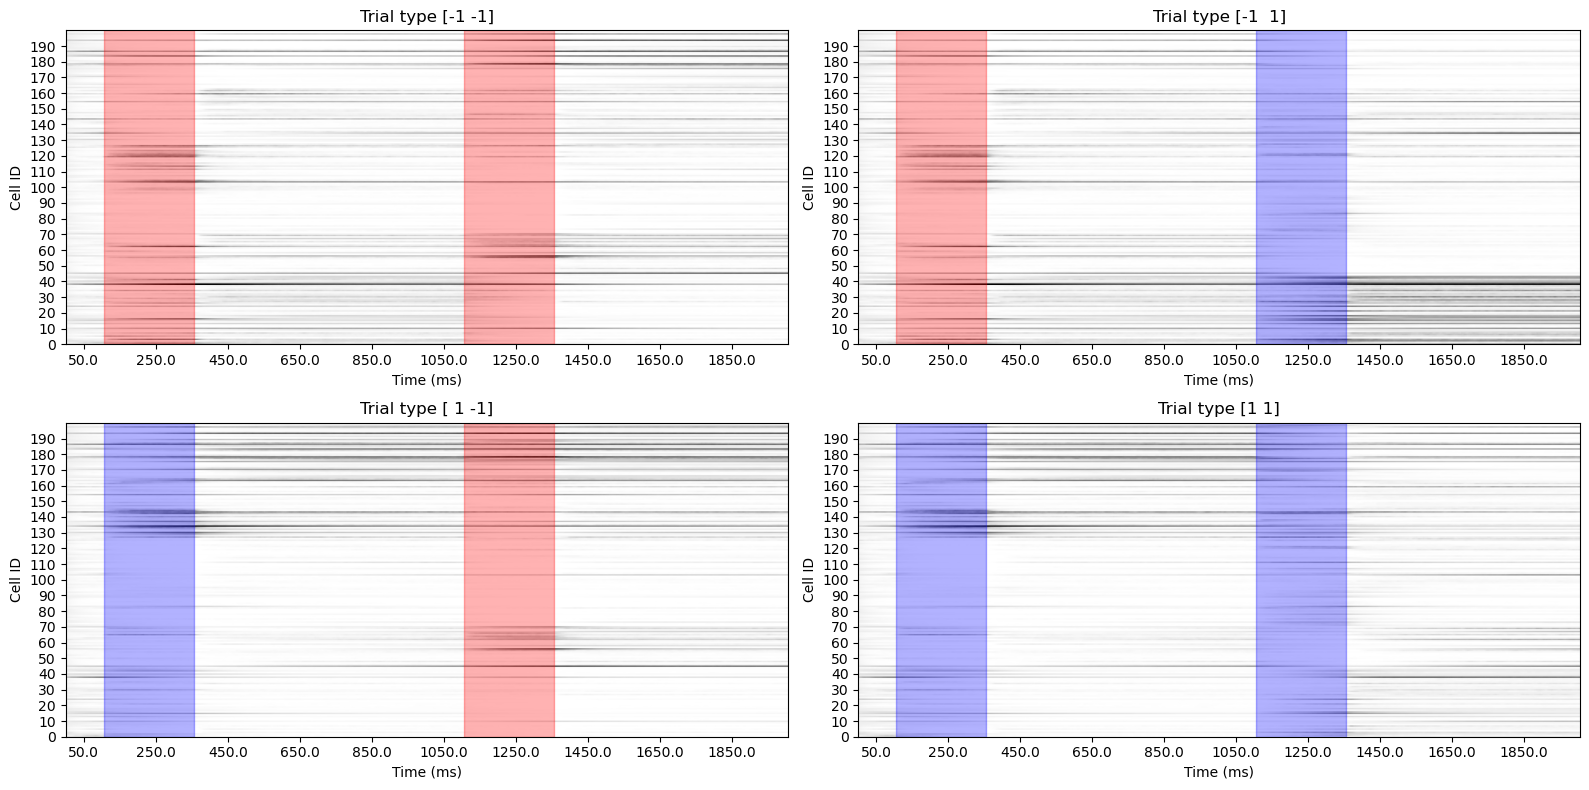

In [ ]:
importlib.reload(sn)
sort = np.argsort(labels)
sn.plot_trialtype_meanrates(model_name, condn_phrase, condn_num, rates_data = rates_data, cut_off=50, sort=sort)

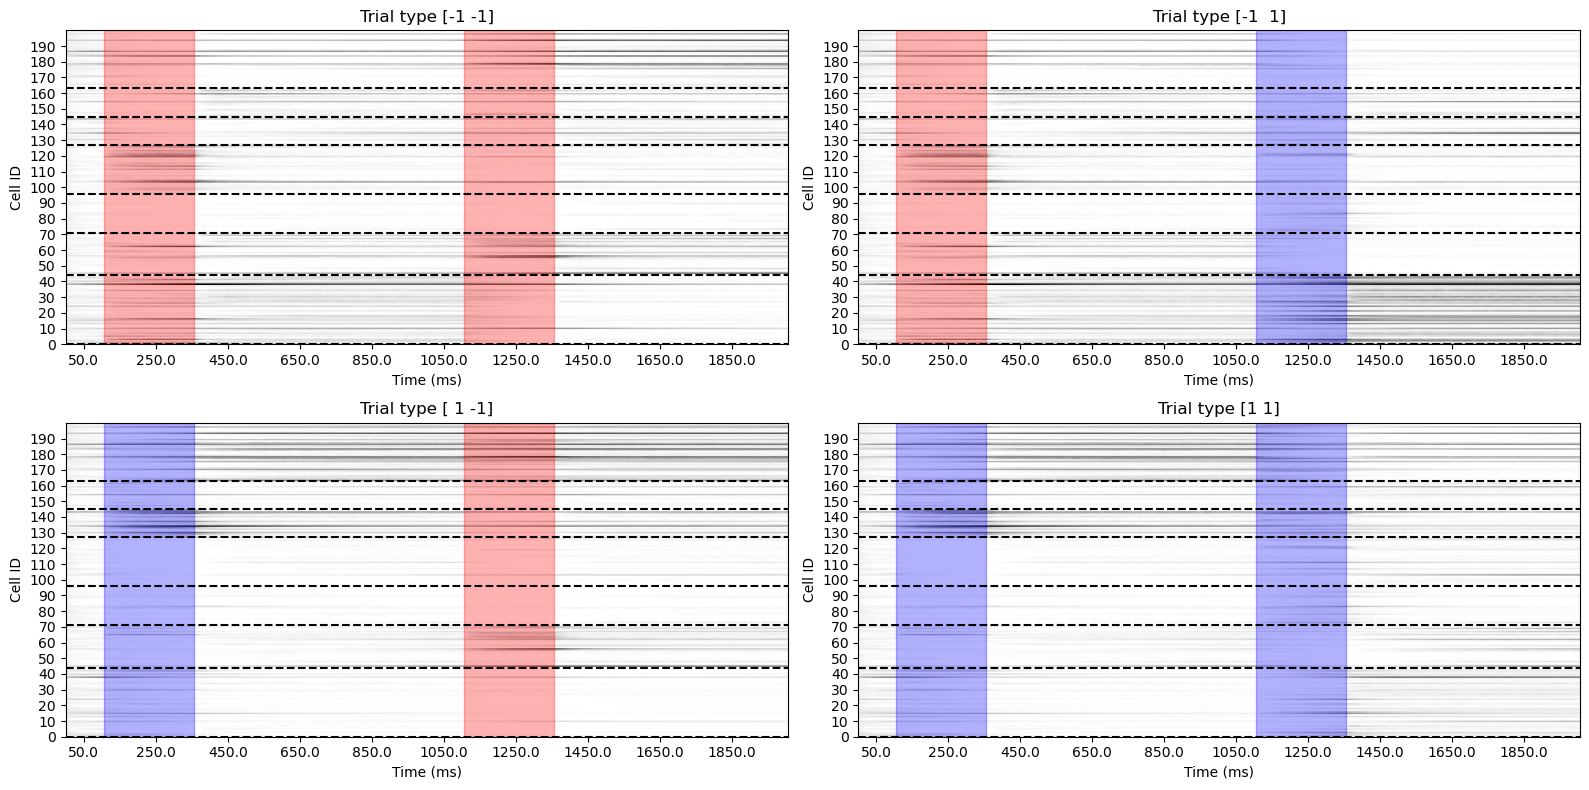

In [ ]:
importlib.reload(sn)
sort = np.argsort(labels)
_, hlines = np.unique(np.sort(labels), return_index=True)
sn.plot_trialtype_meanrates(model_name, condn_phrase, condn_num, rates_data = rates_data, cut_off=50, sort=sort, hlines=hlines)

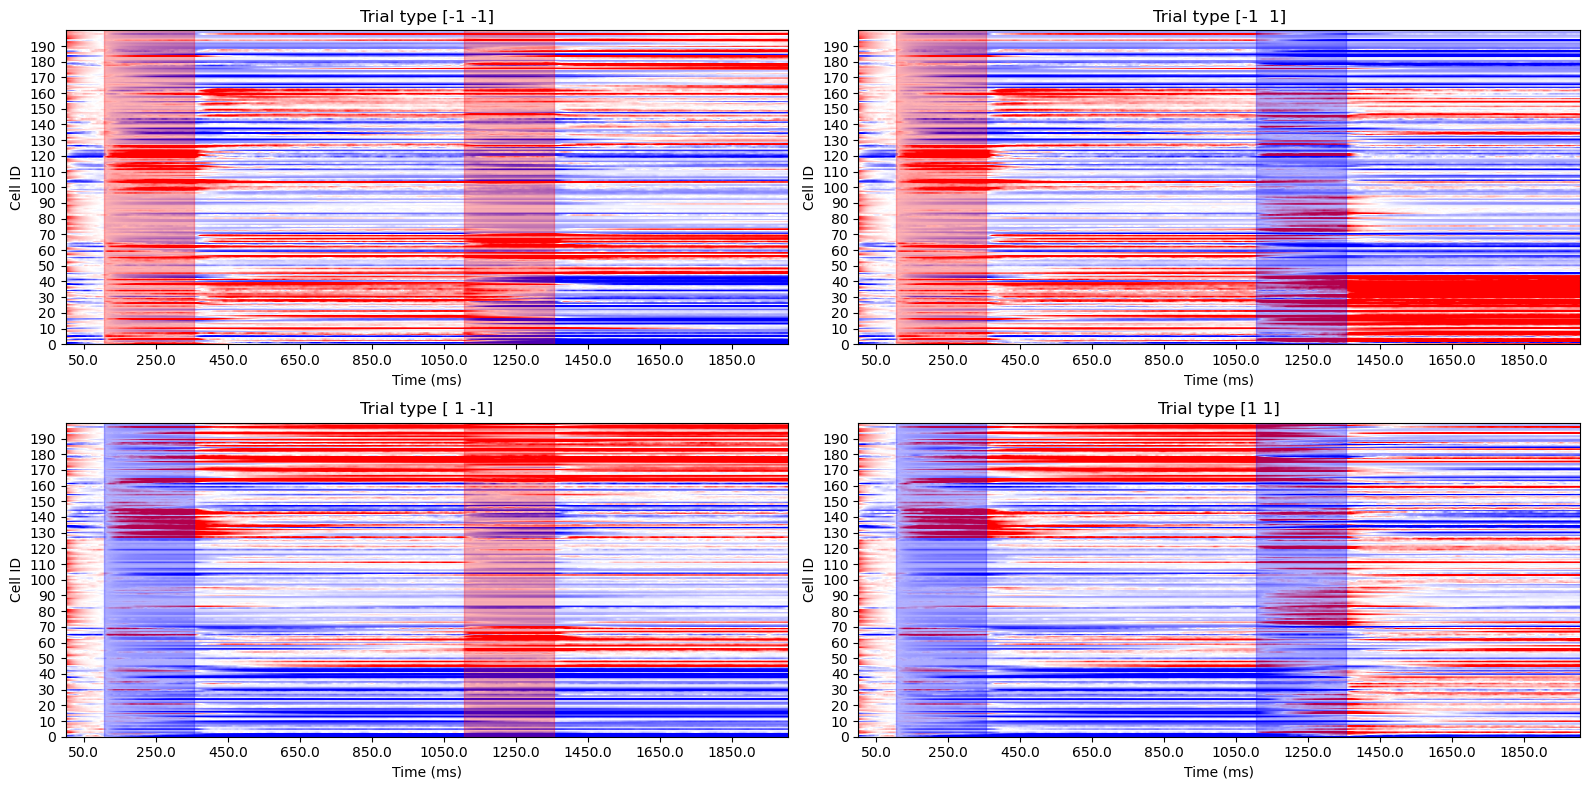

In [ ]:
importlib.reload(sn)
sort = np.argsort(labels)
_, hlines = np.unique(np.sort(labels), return_index=True)
sn.plot_trialtype_meanrates(model_name, condn_phrase, condn_num, rates_data = rates_data, cut_off=50, sort=sort, normalize=True,
                            hlines = [])
# baseline subtracted

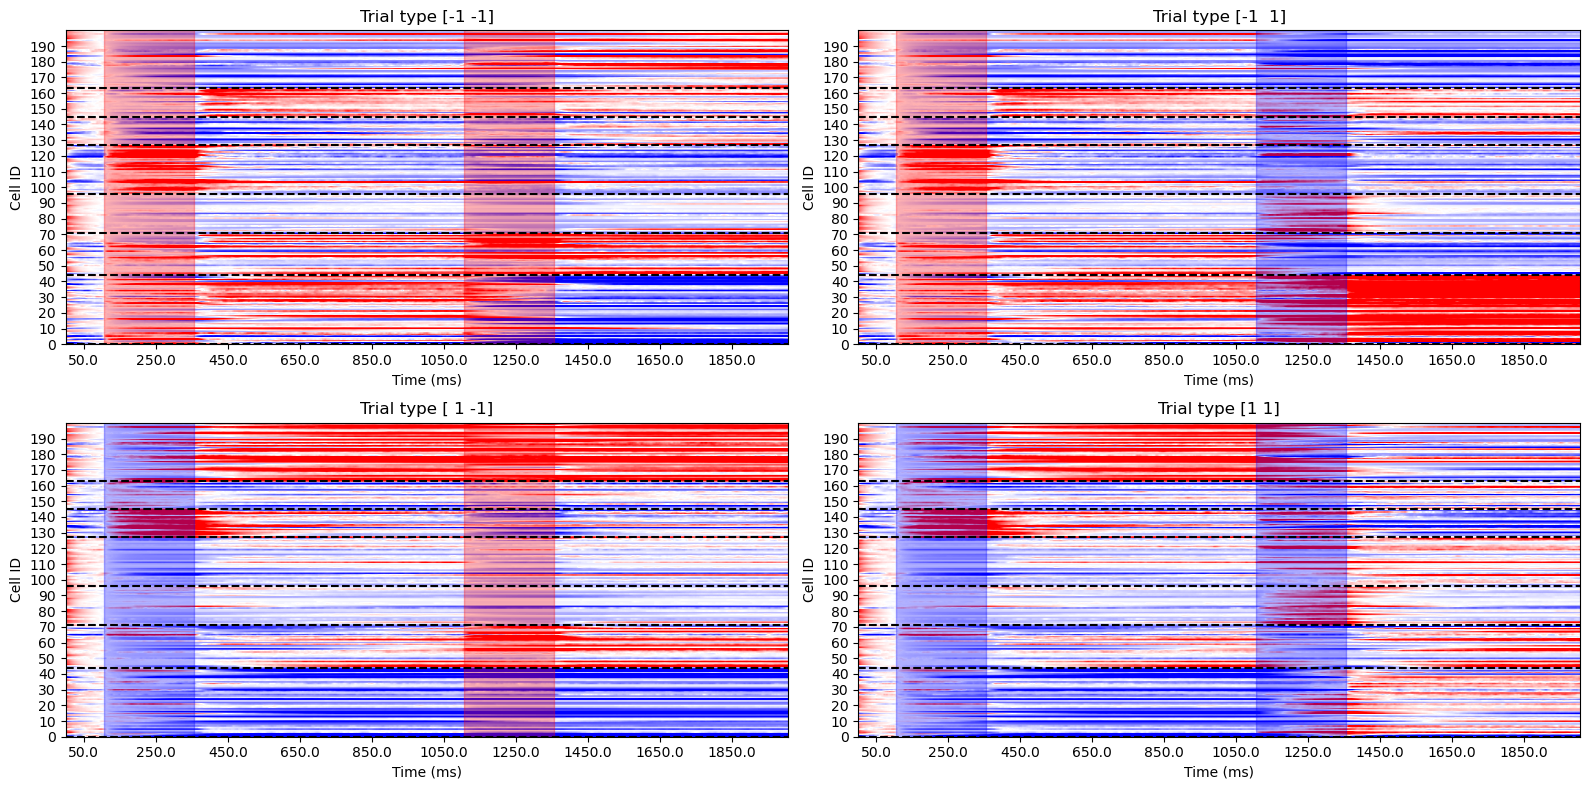

In [ ]:
importlib.reload(sn)
sort = np.argsort(labels)
_, hlines = np.unique(np.sort(labels), return_index=True)
sn.plot_trialtype_meanrates(model_name, condn_phrase, condn_num, rates_data = rates_data, cut_off=50, sort=sort, normalize=True,
                            hlines = hlines)
# baseline subtracted

/home/nuttidalab/miniconda3/envs/rnn_test/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


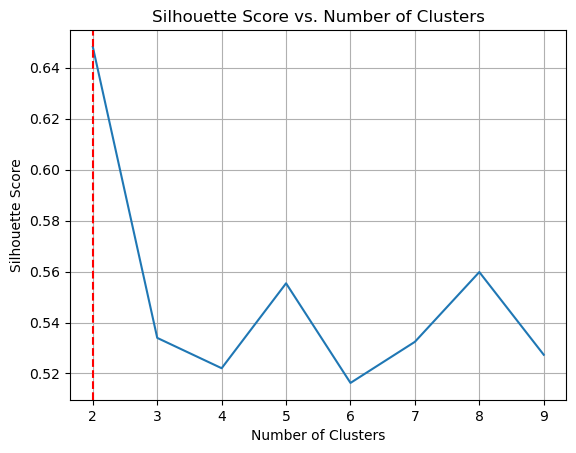

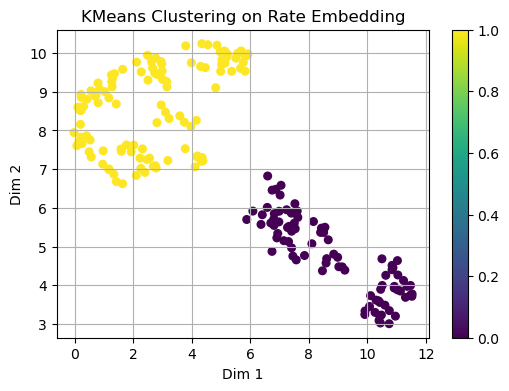

In [121]:
# try just on rate data

# do kmeans clustering on embedding

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

embedding_rate = embed_umap(rate_features, dim=2)

scores = []
for k in range(2,10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(embedding_rate)
    labels = kmeans.labels_
    score = silhouette_score(embedding_rate, labels)
    scores.append(score)
    best_k = k if (score == max(scores)) else best_k
plt.plot(range(2,10), scores)
plt.axvline(x=best_k, color='r', linestyle='--')
plt.title("Silhouette Score vs. Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

kmeans = KMeans(n_clusters=best_k, random_state=42)
kmeans.fit(embedding_rate)
labels = kmeans.labels_
plt.figure(figsize=(6,4))
plt.scatter(embedding_rate[:, 0], embedding_rate[:, 1], c=labels, s=30)
plt.title("KMeans Clustering on Rate Embedding")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.grid(True)
plt.colorbar()
plt.show()

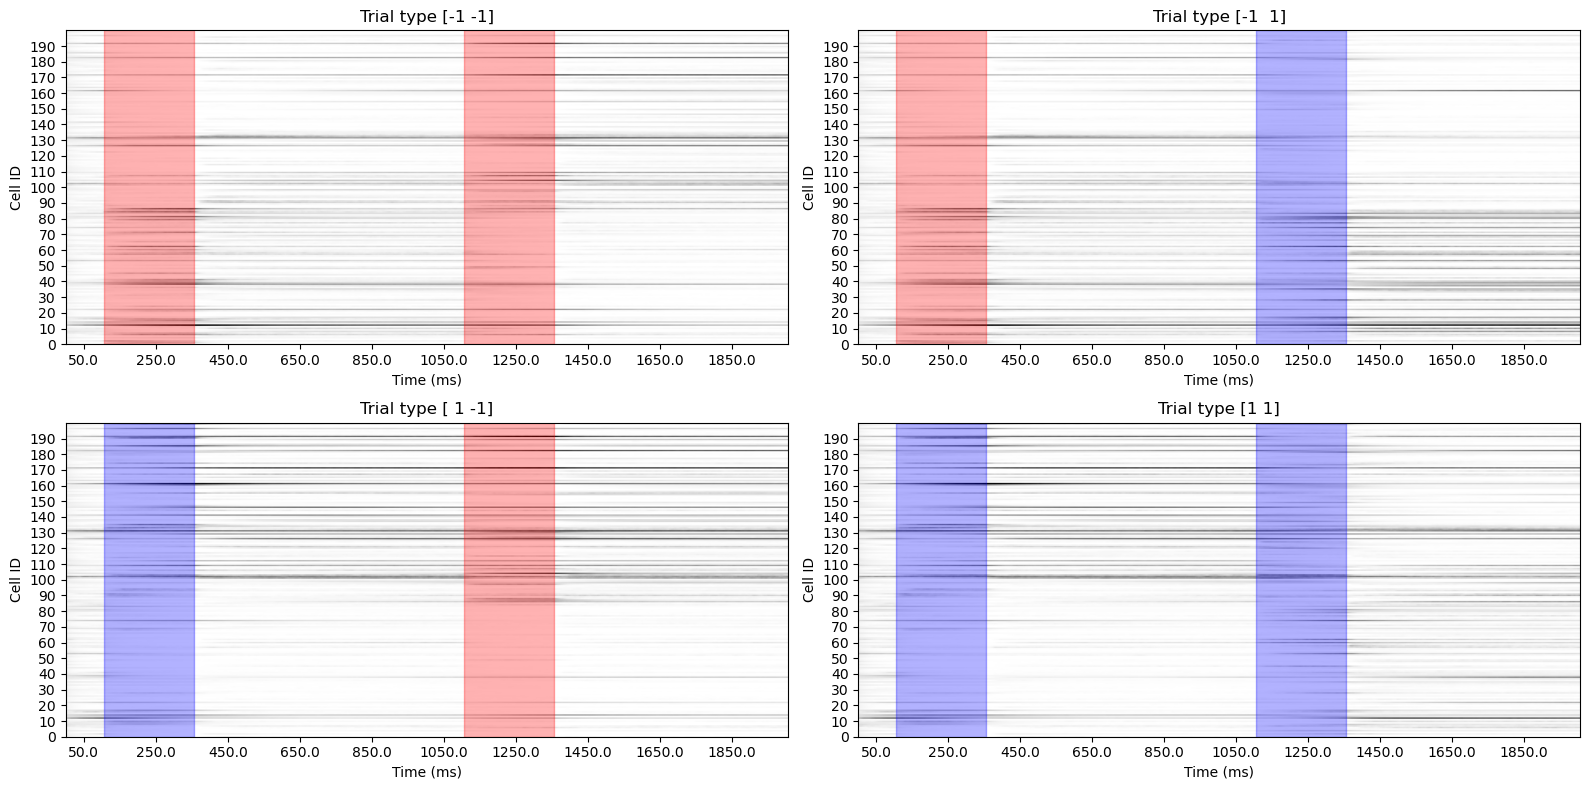

In [122]:
importlib.reload(sn)
sort = np.argsort(labels)
sn.plot_trialtype_meanrates(model_name, condn_phrase, condn_num, rates_data = rates_data, cut_off=50, sort=sort)